# Predicting Bike-Sharing Demand Using Statistical Analysis and Machine Learning

## 1. Introduction

Bike-sharing systems provide an important form of urban transportation, and understanding changes in bicycle demand can help operators improve resource allocation and service planning.

In this project, I analyse the UCI Bike Sharing Dataset to investigate factors associated with bike rentals demand and develop machine learning models for predicting hourly bike rental demand based on factors such as time, working-day status, weather and temperature.

The analysis focuses on patterns in rental demand across different hours, working days, weather conditions and temperatures. I then compare Linear Regression and Random Forest models using a chronological train-test split to evaluate how well they generalize to later, unseen observations.

The project combines exploratory data analysis, statistical reasoning, data visualization and machine learning using Python. 

## 2. Loading the Dataset
The dataset used in this project is the UCI Bike Sharing Dataset. It contains hourly records of bike rental demand together with information about time, weather conditions, temperature, humidity and wind speed.
The target variable is `cnt`, which represents the total number of bike rentals during each hour.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/hour.csv")

## 3. Data Inspection and Cleaning
Before conducting the analysis, the dataset was inspected to understand its structure, data types, summary statistics, and completeness. The dataset contains hourly bike rental records from 2011 to 2012, together with information on time, weather and seasonal conditions. The UCI Machine Learning Repository reports that the dataset has no missing values.

### 3.1 Dataset Structure and Summary

The dataset contains 17,379 hourly observations and 17 columns. These variables include information about the date, season, hour of the day, working-day status, weather conditions, temperature, humidity, wind speed, and bike rental counts.

The target variable, `cnt`, represents the total number of bike rentals and is calculated from the counts of casual and registered users. The dataset covers the period from January 2011 to December 2012.

The intial inspection showed that the dataset contains no missing values. The `dteday` variable was stored as text and was therefore converted to a datetime format to make it suitable for data-based analysis.

The descrptive statistics also showed substantial variation in hourly rental demand, with the number of rentals ranging from 1 to 977.

In [3]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [4]:
df.shape

(17379, 17)

In [5]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [7]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


### 3.2 Data Cleaning
The `dteday` variable was initially stored as text, so it was converted to a datetime format. This allows the date to be handled correctly in later analysis.
The dataset documentation reports no missing values, so no missing-value imputation was required.

In [8]:
df['dteday'] = pd.to_datetime(df['dteday'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.groupby('hr')['cnt'].mean()

hr
0      53.898072
1      33.375691
2      22.869930
3      11.727403
4       6.352941
5      19.889819
6      76.044138
7     212.064649
8     359.011004
9     219.309491
10    173.668501
11    208.143054
12    253.315934
13    253.661180
14    240.949246
15    251.233196
16    311.983562
17    461.452055
18    425.510989
19    311.523352
20    226.030220
21    172.314560
22    131.335165
23     87.831044
Name: cnt, dtype: float64

## 4. Exploratory Data Analysis
Exploratory data analysis was conducted to identify patterns and relationships in bike rental demand before building the machine learning models. The analysis focused on how rental demand varies by hour of the day, working-day status, weather conditions, and temperature.

### 4.1 Bike Rental Demand by Hour
The average number of bike rentals was calculated for each hour of the day to identify periods of high and low demand.

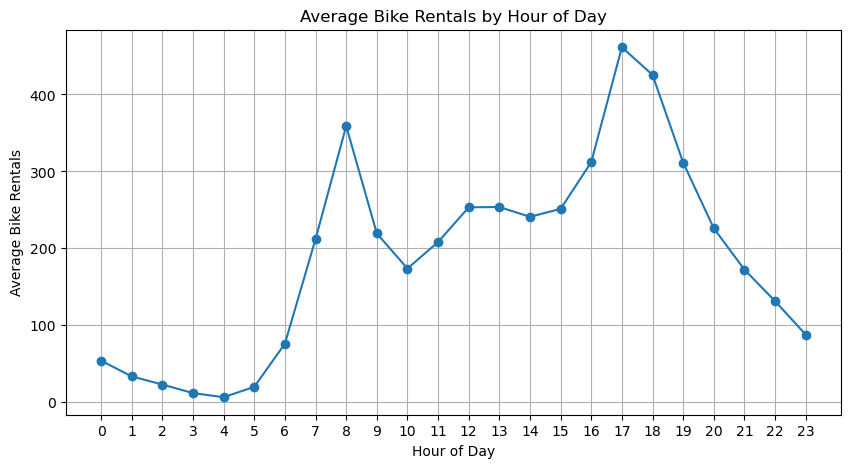

In [12]:
import matplotlib.pyplot as plt

hourly = df.groupby('hr')['cnt'].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly.index, hourly.values, marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Average Bike Rentals')
plt.title('Average Bike Rentals by Hour of Day')
plt.xticks(range(24))
plt.grid()
plt.show()


The results show a clear variation in the bike rental throughout the day. Hour 17 (5:00 PM) recorded the highest average rental demand, at approximately 461 rentals per hour, while hour 4 (4:00 AM) recorded the lowest, at approximately 6 rentals per hour.

This large difference suggests that time of the day is strongly associated with bike rental demand. The high demand during the late afternoon may reflect increased travel activity around the end of the working day, while the very low demand during the early morning hours is consistent with lower overall activity during that period.

These results indicate that the hour of the day is likely to be an important predictor of bike rental demand in the machine learning models.

### 4.2 Working Day vs Non-Working Day
To examine whether daily schedule affects rental demand, average hourly bike rentals were compared between working and non-working days.
The comparison was made separately for each hour of the day rather than using overall daily averages. This helps reveal whether the relationship between working-day status and rental demand changes throughout the day.

In [13]:
hourly_working = df.groupby(['hr', 'workingday'])['cnt'].mean().unstack()

hourly_working

workingday,0,1
hr,,
0,90.800000,36.786290
1,69.508696,16.552632
2,53.171053,8.683778
3,25.775330,4.942553
4,8.264317,5.429787
5,8.689189,24.913131
6,18.742358,102.500000
7,43.406926,290.612903
8,105.653680,477.006048


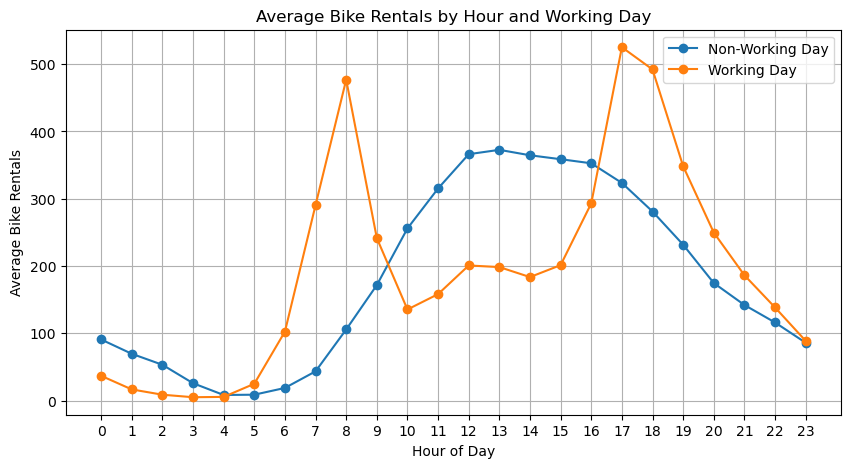

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(hourly_working.index, hourly_working[0], marker='o', label='Non-Working Day')

plt.plot(hourly_working.index, hourly_working[1], marker='o', label='Working Day')

plt.xlabel('Hour of Day')
plt.ylabel('Average Bike Rentals')
plt.title('Average Bike Rentals by Hour and Working Day')
plt.xticks(range(24))
plt.legend()
plt.grid()

plt.savefig("../figures/Working_vs_NonWorking_Day.png")
plt.show()

The results show different hourly demand patterns between working days and non-working days. During the early morning hours, particularly around 12:00 AM to 4:00 AM, non-working days generally show higher average demand. In contrast,working days show substantially higher demand during the evening, with the difference being particularly noticeable around 5:00 PM.

At 5:00 PM, for example, average demand on working days was approximately 525 rentals, compared with approximately 324 rentals on non-working days.

These differences suggest that the effect of working-day status is not uniform throughout the day. Instead, its relationship with rental demand appears to interact with the time of the day. This makes `workingday` a potentially useful predictor alongside `hr` in the machine learning models.

### 4.3 Weather and Bike Rental Demand
To examine the relationship between weather conditions and bike rental demand, the average number of rentals was calculated for each weather category.
The weather variable ranges from 1 to 4 , where lower values represent clearer conditions and higher values represent more severe conditions.

In [15]:
weather_demand = df.groupby('weathersit')['cnt'].mean()

weather_demand

weathersit
1    204.869272
2    175.165493
3    111.579281
4     74.333333
Name: cnt, dtype: float64

The results show a clear decline in average bike rental demand as weather conditions become less favorable. Average demand was approximately 205 rentals under weather category 1, compared with approximately 175 rentals under category 2, 112 rentals under category 3, and 74 rentals under category 4.

This pattern suggests that poorer weather conditions are associated with lower bike rental demand. However, the results describe an association rather than proving that weather conditions directly cause the changes in demand.

Weather conditions were therefore retained as a predictor in the machine learning models.

### 4.4 Temperature and Bike Rental Demand
The relationship between temperature and bike rental demand was examined using the Pearson correlation coefficient and a scatter plot. The correlation measures the strength and direction of the linear relationship between the two variables.

In [16]:
df[['temp', 'cnt']].corr()

,temp,cnt
temp,1.000000,0.404772
cnt,0.404772,1.000000


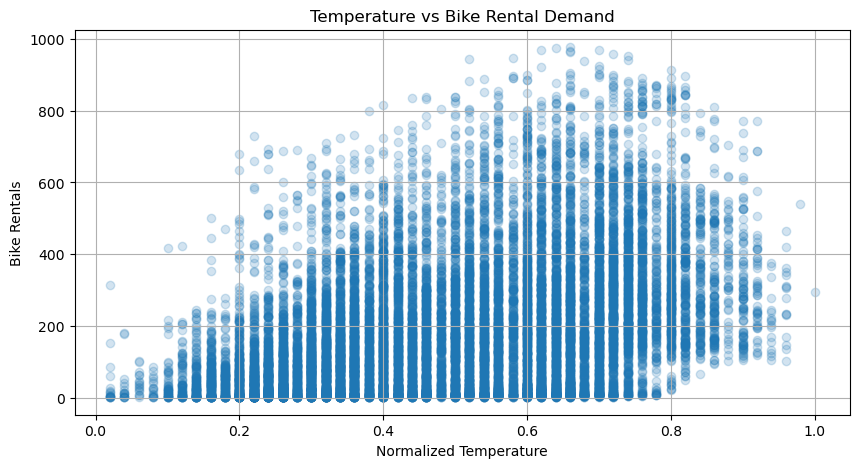

In [17]:
plt.figure(figsize=(10, 5))

plt.scatter(df['temp'], df['cnt'], alpha=0.2)

plt.xlabel('Normalized Temperature')
plt.ylabel('Bike Rentals')
plt.title('Temperature vs Bike Rental Demand')

plt.grid()
plt.savefig("../figures/temperature_vs_bike_rentals.png")
plt.show()

The Pearson correlation coefficient between temperature and bike rental demand was approximately o.405. This indicates a moderate positive linear association: higher temperatures tend to be associated with higher bike rental demand.

The scatter plot also shows a generally upward pattern, although the observations are widely dispersed. This indicates that temperature alone does not explain all of the variation in rental demand. Other factors, such as hour of the day, working-day status, and weather conditions, are also likely to contribute to demand.

Therefore, temperature was retained as one of the predictors for the machine learning models.

## 5. Machine Learning

Following the exploratory analysis, machine learning models were developed to predict hourly bike rental demand. Linear Regression was used as a baseline model, while Random Forest Regression was used as a nonlinear ensemble model.

The models were evaluated using Mean Absolute Error (MAE) and the coefficient of determination (R²). A chronological train-test split was also used so that later observations were evaluated as unseen data.

### 5.1 Preparing the Data

The target variable is `cnt`, representing the total number of bike rentals per hour. The variables used as predictors include time, seasonal, calendar, and weather-related characteristics.

The variables `casual` and `registered` were excluded because they are components of the target variable `cnt`. Including them would introduce information that would not be available when predicting total demand.

In [18]:
x = df.drop(columns=['cnt', 'casual', 'registered', 'instant'])

y = df['cnt']

In [19]:
x.columns

Index(['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed'],
      dtype='object')

In [20]:
x = x.drop(columns=['dteday'])

In [21]:
x.columns

Index(['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed'],
      dtype='object')

### 5.2 Train-Test Split

The data was divided into training and testing sets while preserving the chronological order of the observations. The first 80% of the observations were used for training, while the remaining 20% were used for testing.

This approach allows the models to be trained on earlier observations and evaluated on later, unseen observations. It therefore provides a more realistic assessment of predictive performance for time-ordered data.

In [22]:
# Find the point where we split the data into 80% training and 20% testing
split_index = int(len(df) * 0.8)

# Training data: the ealier 80% 
x_train_time = x.iloc[:split_index]
y_train_time = y.iloc[:split_index]

#Testing data: the later 20%
x_test_time = x.iloc[split_index:]
y_test_time = y.iloc[split_index:]

print("Training observations:", len(x_train_time))
print("Testing observations:", len(x_test_time))

Training observations: 13903
Testing observations: 3476


### 5.3 Linear Regression

Linear Regression was used as a baseline model. It assumes that the relationship between the predictors and bike rental demand can be represented using a linear combination of the input variables.

The model provides a useful benchmark against which the more flexible Random Forest model can be compared.

In [23]:
from sklearn.linear_model import LinearRegression

linear_time_model = LinearRegression()
linear_time_model.fit(x_train_time, y_train_time)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
linear_time_pred = linear_time_model.predict(x_test_time)

In [25]:
from sklearn.metrics import mean_absolute_error, r2_score

linear_time_mae = mean_absolute_error(y_test_time, linear_time_pred)
linear_time_r2 = r2_score(y_test_time, linear_time_pred)

print("Linear Regression MAE:", linear_time_mae)
print("Linear Regression R²:", linear_time_r2)

Linear Regression MAE: 138.29175310827318
Linear Regression R²: 0.30902462052952806


### 5.4 Random Forest Regression

Random Forest Regression was used as a second model because it can capture nonlinear relationships and interactions between predictors.

The model combines predictions from multiple decision trees and can therefore represent more complex relationships between factors such as hour, temperature, working-day status, and weather conditions.

In [26]:
from sklearn.ensemble import RandomForestRegressor

rf_model_time = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model_time.fit(x_train_time, y_train_time)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
rf_time_pred = rf_model_time.predict(x_test_time)

In [28]:
rf_time_mae = mean_absolute_error(y_test_time, rf_time_pred)
rf_time_mae

44.99078528960492

In [29]:
rf_time_r2 = r2_score(y_test_time, rf_time_pred)
rf_time_r2

0.900475864109326

### 5.5 Model Comparison

The two models were compared using Mean Absolute Error (MAE) and R². MAE represents the average absolute difference between the observed and predicted rental counts, while R² represents the proportion of variation in rental demand explained by the model.

In [30]:
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [linear_time_mae, rf_time_mae],
    'R²': [linear_time_r2, rf_time_r2]
})

model_comparison

,Model,MAE,R²
0,Linear Regression,138.291753,0.309025
1,Random Forest,44.990785,0.900476


## 6. Feature Importance

Feature importance was examined using the Random Forest model to identify which predictors contributed most strongly to the model's predictions.

The importance values indicate how useful each feature was to the fitted Random Forest model. They should be interpreted as measures of model-based importance rather than as evidence that a feature directly causes changes in rental demand.

In [31]:
feature_importance = pd.Series(rf_model_time.feature_importances_, index=x_train_time.columns)

feature_importance.sort_values(ascending=False)

hr            0.605899
atemp         0.085952
temp          0.081636
yr            0.068528
workingday    0.057241
hum           0.027827
weathersit    0.019219
mnth          0.013868
season        0.013332
weekday       0.013054
windspeed     0.010949
holiday       0.002494
dtype: float64

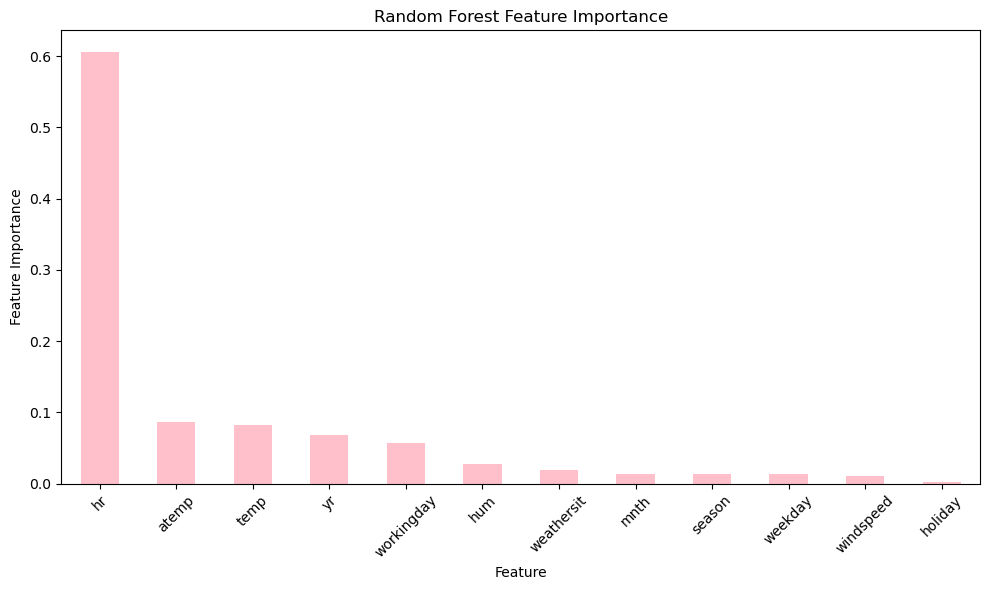

In [32]:
feature_importance.sort_values(ascending=False).plot(kind='bar', figsize=(10, 6), color='pink')

plt.xlabel('Feature')
plt.ylabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../figures/feature_importance.png", dpi=300)
plt.show()

The hour of the day was the most important predictor, with an importance value of approximately 0.606. This indicates that the time of day played a substantially larger role in the Random Forest's predictions than the other variables.

Feeling temperature (`atemp`) and temperature (`temp`) were the next most important variables, followed by year and working-day status.

These results are consistent with the exploratory analysis, which showed strong differences in rental demand across hours and a positive association between temperature and demand.

## 7. Actual vs Predicted Rental Demand

The predicted rental counts were compared with the observed rental counts to assess how closely the Random Forest model reproduced the actual demand.

A well-performing model should produce predictions that generally follow the observed values, with points concentrated around the ideal relationship between actual and predicted demand.

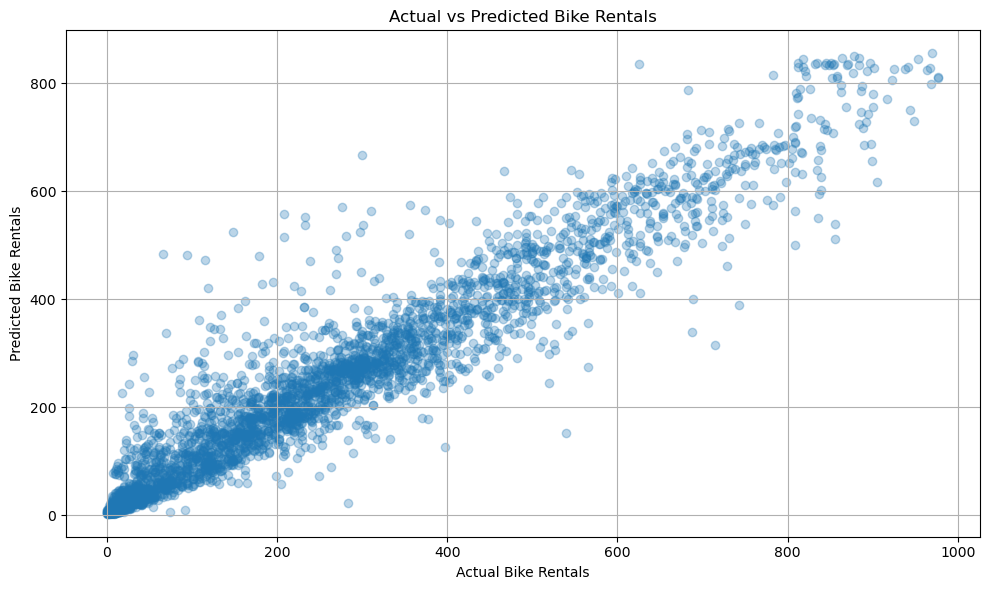

In [33]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test_time, rf_time_pred, alpha=0.3)

plt.xlabel('Actual Bike Rentals')
plt.ylabel('Predicted Bike Rentals')
plt.title('Actual vs Predicted Bike Rentals')

plt.grid()
plt.tight_layout()
plt.savefig("../figures/actual_vs_predicted.png", dpi=300)
plt.show()

The plot shows that the model predictions generally follow the observed rental demand, although some differences remain, particularly for observations with unusually high or low rental counts.

The model therefore captures much of the variation in hourly demand but does not reproduce every observation exactly.

## 8. Residual Analysis

Residuals were examined to assess the difference between the observed rental counts and the values predicted by the Random Forest model.

A residual is calculated as the observed value minus the predicted value. If predictions are accurate, residuals should generally be centered around zero without a strong systematic pattern.

In [34]:
errors = y_test_time - rf_time_pred

errors.describe()

count    3476.000000
mean       16.479921
std        67.586599
min      -417.680000
25%        -7.960000
50%         8.105000
75%        44.215000
max       400.860000
Name: cnt, dtype: float64

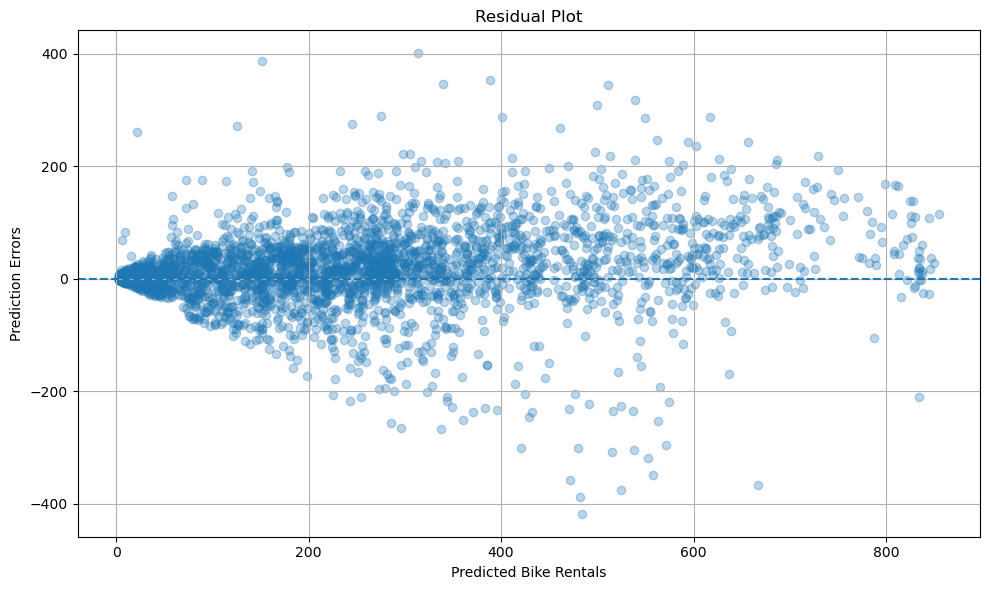

In [35]:
plt.figure(figsize=(10, 6))

plt.scatter(rf_time_pred, errors, alpha=0.3)

plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Bike Rentals')
plt.ylabel('Prediction Errors')
plt.title('Residual Plot')

plt.grid()

plt.tight_layout()
plt.savefig("../figures/residual_plot.png", dpi=300)
plt.show()

The residual plot shows that many observations are concentrated around the zero line, indicating that the model's predictions are relatively close to the observed values for a large proportion of the test observations.

However, some larger positive and negative residuals are present. These indicate observations for which the model substantially underpredicted or overpredicted rental demand.

Overall, the residuals do not show an obvious strong systematic pattern, supporting the conclusion that the Random Forest model captures much of the structure in the data.

In [36]:
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [105, rf_time_mae],
    'R2': [0.3879811583, rf_time_r2]
})

model_comparison

,Model,MAE,R2
0,Linear Regression,105.000000,0.387981
1,Random Forest,44.990785,0.900476


In [37]:
linear_time_model = LinearRegression()

linear_time_model.fit(x_train_time, y_train_time)

linear_time_pred = linear_time_model.predict(x_test_time)

In [38]:
linear_time_mae = mean_absolute_error(y_test_time, linear_time_pred)

linear_time_r2 = r2_score(y_test_time, linear_time_pred)

print("Linear Regression MAE:", linear_time_mae)
print("Linear Regression R2:", linear_time_r2)

Linear Regression MAE: 138.29175310827318
Linear Regression R2: 0.30902462052952806


## 9. Final Model Results

The chronological evaluation showed that the Random Forest model achieved lower prediction error and a higher R² than the Linear Regression baseline.

This indicates that the Random Forest model captured nonlinear relationships and interactions in the predictors that were not adequately represented by the linear model.

The Random Forest model was therefore used for the subsequent feature-importance and prediction-diagnostic analyses.

## 10. Key Findings

Several important patterns emerged from the analysis:

- Bike rental demand varied substantially throughout the day, with the highest average demand occurring around 5:00 PM and the lowest occurring during the early morning hours.
- Working-day status was associated with different hourly demand patterns, particularly around commuting periods.
- Average rental demand generally decreased as weather conditions became less favorable.
- Temperature showed a moderate positive association with rental demand, with a Pearson correlation of approximately 0.405.
- The Random Forest model substantially outperformed the Linear Regression baseline on the evaluation metrics used.
- Hour of the day was the most important feature in the Random Forest model, followed by feeling temperature, temperature, year, and working-day status.

## 11. Limitations

This analysis has several limitations.

First, the dataset represents bike-sharing activity in the Capital Bikeshare system during 2011 and 2012, so the patterns may not generalize to other cities, time periods, or bike-sharing systems.

Second, the model uses the variables available in the dataset and therefore does not account for other factors that could influence demand, such as major events, traffic conditions, public transport disruptions, or changes in bike availability.

Third, the Random Forest feature importance values describe the contribution of variables to the fitted model and should not be interpreted as causal effects.

Finally, the analysis evaluates prediction performance on later observations within the available dataset. It should not be interpreted as evidence that the model will maintain the same accuracy over an arbitrary future forecasting period.

## 12. Conclusion

This project investigated patterns in hourly bike rental demand and developed machine learning models to predict rental counts using time, calendar, seasonal, and weather-related variables.

The exploratory analysis showed substantial variation in demand across hours of the day, differences between working and non-working days, lower demand under poorer weather conditions, and a moderate positive association between temperature and rental demand.

Two regression models were evaluated. Linear Regression provided a baseline, while Random Forest Regression was able to capture more complex relationships between the predictors and rental demand. In the evaluation conducted, the Random Forest model produced substantially lower prediction error and higher explanatory performance than Linear Regression.

Overall, the analysis demonstrates how statistical exploration and machine learning can be combined to understand and predict demand in a bike-sharing system.